<a href="https://colab.research.google.com/github/rocio-mr/hierarchical-clustering-mcd/blob/main/Actividad_8_Clustering_Jer%C3%A1rquico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PARTE I:

Encontrar grupos en el dataset “20 Newsgroups Dataset” de scikit-learn a través de clustering jerárquico. Debe demostrar que se ha probado por lo menos dos criterios diferentes de Linkage y determinar cuál ha tenido más éxito. Además explique los hallazgos que ha realizado el clustering.

In [1]:
#Importar las librerías necesarias

from sklearn.datasets import fetch_20newsgroups
import numpy as np

In [2]:
#Carga del dataset completo
df_newgroups = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes"), #Quitar metadatos que podrían influir negativamente en los modelos más adelante
)

In [3]:
#Explorar el dataset
textos = df_newgroups.data
#Imprimir el primer valor
textos[0]

"\n\nI am sure some bashers of Pens fans are pretty confused about the lack\nof any kind of posts about the recent Pens massacre of the Devils. Actually,\nI am  bit puzzled too and a bit relieved. However, I am going to put an end\nto non-PIttsburghers' relief with a bit of praise for the Pens. Man, they\nare killing those Devils worse than I thought. Jagr just showed you why\nhe is much better than his regular season stats. He is also a lot\nfo fun to watch in the playoffs. Bowman should let JAgr have a lot of\nfun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final\nregular season game.          PENS RULE!!!\n\n"

In [5]:
#Categorías del dataset
categorias = df_newgroups.target
categorias

array([10,  3, 17, ...,  3,  1,  7])

In [6]:
#Imprimir los nombres de las 20 categorías
nombres_categorias = df_newgroups.target_names
nombres_categorias

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

**Debido al tamaño del dataset se optó por tomar una muestra estratificada de 200 documentos como experimento y así evaluar su comportamiento**

In [8]:
#Inicializar la semilla
np.random.seed(42)

indices_muestra = []

#Seleccionar 10 documentos por cada categoría
for categoria in range(len(nombres_categorias)):
  #índices de los documentos que pertenecen a la categoría
  indices_categoria = np.where(categorias == categoria)[0]

  #Seleccionar 10 documentos aleatorios
  seleccionados = np.random.choice(
      indices_categoria,
      size=10,
      replace=False
  )

  #Agregar los índices seleccionados a la lista
  indices_muestra.extend(seleccionados)

#Convertir a array
indice_muestra = np.array(indices_muestra)

#Obtener textos y categorías de la muestra
textos_muestra = [textos[i] for i in indices_muestra]
categorias_muestra = categorias[indices_muestra]

In [9]:
#Comprobar el tamaño de la muestra
print(f"Total de documentos seleccionados: {len(textos_muestra)}")

Total de documentos seleccionados: 200


In [10]:
#Comprobar el número de textos por categoría
print("\nDistribución de la muestra:\n")

for i, categoria in enumerate(nombres_categorias):

    cantidad = np.sum(categorias_muestra == i)

    print(f"{i:2d} | {categoria:30s} | {cantidad} documentos")


Distribución de la muestra:

 0 | alt.atheism                    | 10 documentos
 1 | comp.graphics                  | 10 documentos
 2 | comp.os.ms-windows.misc        | 10 documentos
 3 | comp.sys.ibm.pc.hardware       | 10 documentos
 4 | comp.sys.mac.hardware          | 10 documentos
 5 | comp.windows.x                 | 10 documentos
 6 | misc.forsale                   | 10 documentos
 7 | rec.autos                      | 10 documentos
 8 | rec.motorcycles                | 10 documentos
 9 | rec.sport.baseball             | 10 documentos
10 | rec.sport.hockey               | 10 documentos
11 | sci.crypt                      | 10 documentos
12 | sci.electronics                | 10 documentos
13 | sci.med                        | 10 documentos
14 | sci.space                      | 10 documentos
15 | soc.religion.christian         | 10 documentos
16 | talk.politics.guns             | 10 documentos
17 | talk.politics.mideast          | 10 documentos
18 | talk.politics.misc           

**Para esta parte de la vectorización se trabaja con un modelo basado en Transformers para la generación de los embeddings, de modo que podremos convertir cada documento en su representación numérica semántica**

In [11]:
!pip install -q sentence-transformers

In [12]:
#Importación del transformer
from sentence_transformers import SentenceTransformer


#Cargamos all-MiniLM-L6-v2 el cual generará un vector de 384 dimensiones por documento
model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [13]:
#Generar los embeddings
embeddings = model.encode(
    textos_muestra,
    show_progress_bar=True
)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

In [14]:
#Comprobar las dimensiones de los embeddings
embeddings.shape

(200, 384)

In [15]:
#Visualizar un embedding
print(embeddings[0])

[-1.50249109e-01  3.53236198e-02  9.24054757e-02 -6.29150793e-02
 -3.77408415e-02  1.05165960e-02 -6.85808584e-02  3.00050452e-02
  6.75798059e-02  1.05970882e-01 -1.69776101e-02  1.20735846e-01
  8.27018842e-02 -5.79940304e-02 -4.87448350e-02 -6.60953075e-02
 -6.36730194e-02 -1.82277430e-02  4.91974987e-02 -4.49322984e-02
 -4.12745290e-02  1.19731888e-01  2.87835975e-03 -1.48852691e-02
  8.57465565e-02  2.71607973e-02 -6.66633546e-02 -1.03055023e-01
 -1.22067286e-03 -8.06069840e-03 -5.34831397e-02 -2.79606264e-02
  2.27898434e-02 -4.04331572e-02 -1.58006921e-02  1.39439758e-02
  5.03515489e-02  1.49786631e-02  1.35009021e-01 -2.11118106e-02
 -6.47738157e-03  1.27927614e-02 -3.09843943e-02 -2.54209270e-03
 -2.19924431e-02  7.08526298e-02 -2.39483397e-02  1.09056354e-01
 -2.37570517e-02  3.49452756e-02  6.92494726e-03  3.15178297e-02
  6.93142563e-02 -5.83051629e-02  5.53228855e-02  2.60193665e-02
 -5.27165420e-02 -3.63491923e-02 -7.72920903e-03  5.37439063e-02
 -5.15941754e-02  4.33836

In [16]:
#Relacionar cada embedding con su categoría para la evaluación el clustering en la parte final
indice = 0

print("Categoría:")
print(nombres_categorias[categorias_muestra[indice]])

print("\nEmbedding:")
print(embeddings[indice])

Categoría:
alt.atheism

Embedding:
[-1.50249109e-01  3.53236198e-02  9.24054757e-02 -6.29150793e-02
 -3.77408415e-02  1.05165960e-02 -6.85808584e-02  3.00050452e-02
  6.75798059e-02  1.05970882e-01 -1.69776101e-02  1.20735846e-01
  8.27018842e-02 -5.79940304e-02 -4.87448350e-02 -6.60953075e-02
 -6.36730194e-02 -1.82277430e-02  4.91974987e-02 -4.49322984e-02
 -4.12745290e-02  1.19731888e-01  2.87835975e-03 -1.48852691e-02
  8.57465565e-02  2.71607973e-02 -6.66633546e-02 -1.03055023e-01
 -1.22067286e-03 -8.06069840e-03 -5.34831397e-02 -2.79606264e-02
  2.27898434e-02 -4.04331572e-02 -1.58006921e-02  1.39439758e-02
  5.03515489e-02  1.49786631e-02  1.35009021e-01 -2.11118106e-02
 -6.47738157e-03  1.27927614e-02 -3.09843943e-02 -2.54209270e-03
 -2.19924431e-02  7.08526298e-02 -2.39483397e-02  1.09056354e-01
 -2.37570517e-02  3.49452756e-02  6.92494726e-03  3.15178297e-02
  6.93142563e-02 -5.83051629e-02  5.53228855e-02  2.60193665e-02
 -5.27165420e-02 -3.63491923e-02 -7.72920903e-03  5.374

In [17]:
#Aplicar PCA tratando de no obtener mucha pérdida de información, por ello, configuramos la varianza al 90%
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


pca_90 = PCA(
    n_components=0.90
)

embeddings_reducidos = pca_90.fit_transform(
    embeddings
)

print("Dimensiones originales:", embeddings.shape)
print("Dimensiones reducidas:", embeddings_reducidos.shape)
print(
    "Varianza explicada:",
    pca_90.explained_variance_ratio_.sum()
)

Dimensiones originales: (200, 384)
Dimensiones reducidas: (200, 100)
Varianza explicada: 0.90016526


In [18]:
#Calcular la matriz de distancias

from scipy.spatial.distance import pdist

distancias = pdist(
    embeddings_reducidos,
    metric='cosine'
)

print("Cantidad de distancias:", len(distancias))

Cantidad de distancias: 19900


In [19]:
#Aplicar clustering jerárquico con un linkage average

from scipy.cluster.hierarchy import linkage

Z_average = linkage(
    distancias,
    method='average'
)

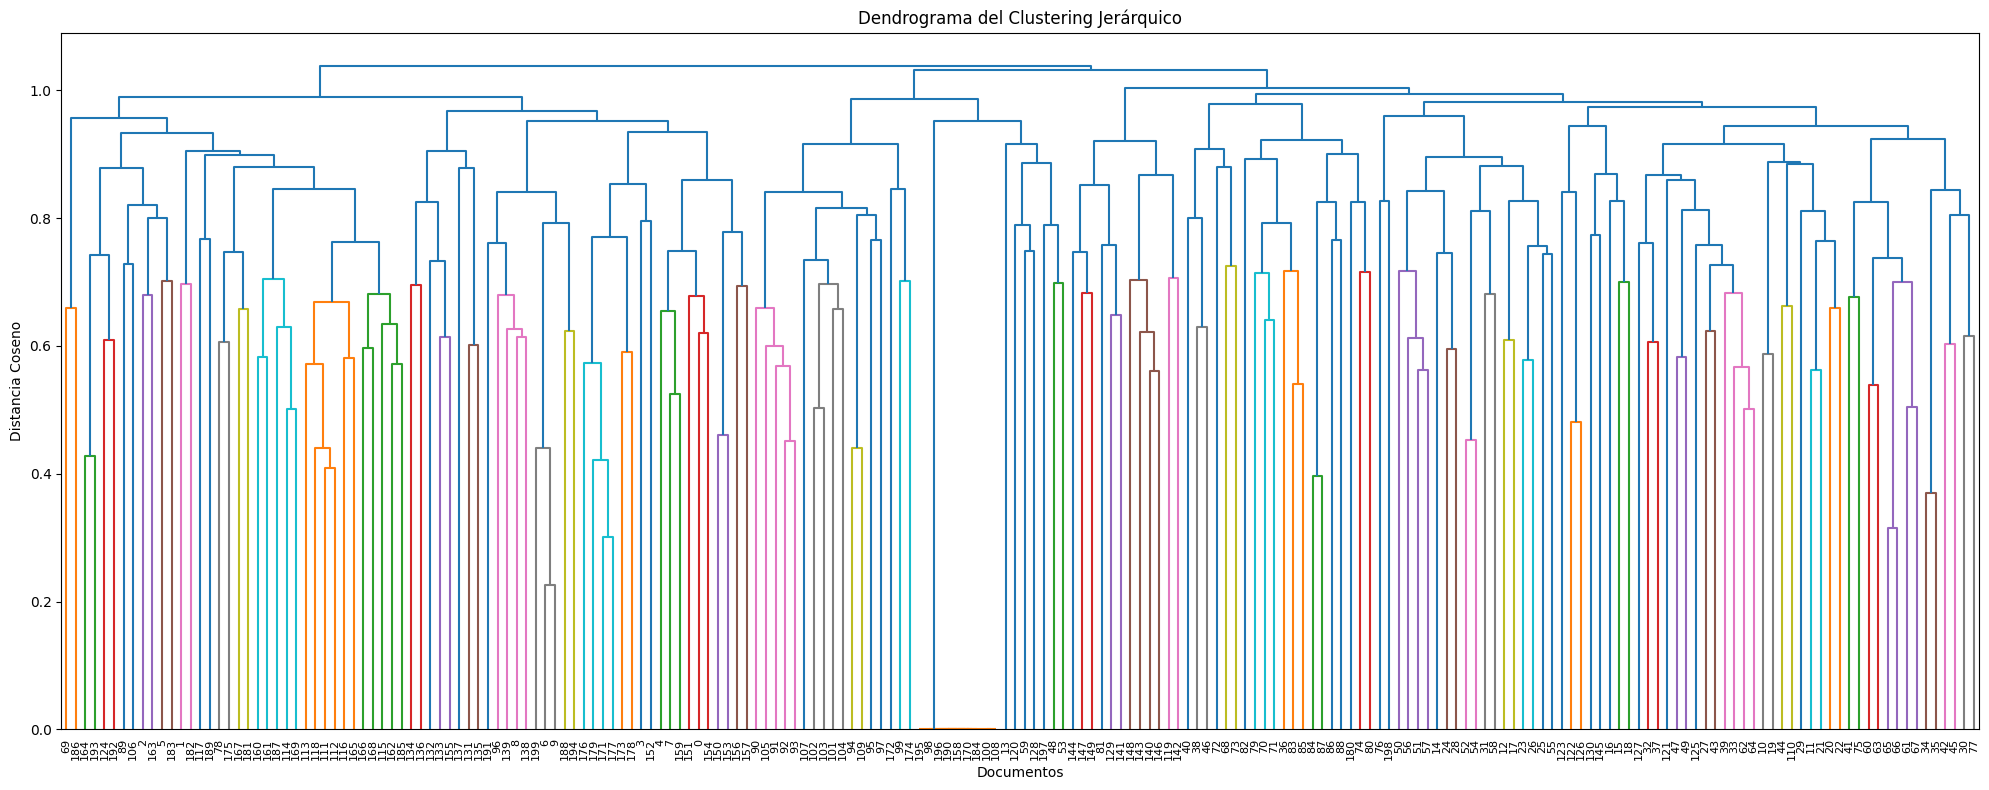

In [21]:
#Gráfico del dendrograma aplicando el linkage "average"
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(20, 8))

dendrogram(
    Z_average,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Dendrograma del Clustering Jerárquico")
plt.xlabel("Documentos")
plt.ylabel("Distancia Coseno")

plt.tight_layout()
plt.show()

In [22]:
#Aplicar agrupamiento jerárquico usando un linkage tipo single
from scipy.cluster.hierarchy import linkage

Z_single = linkage(
    distancias,
    method='single'
)

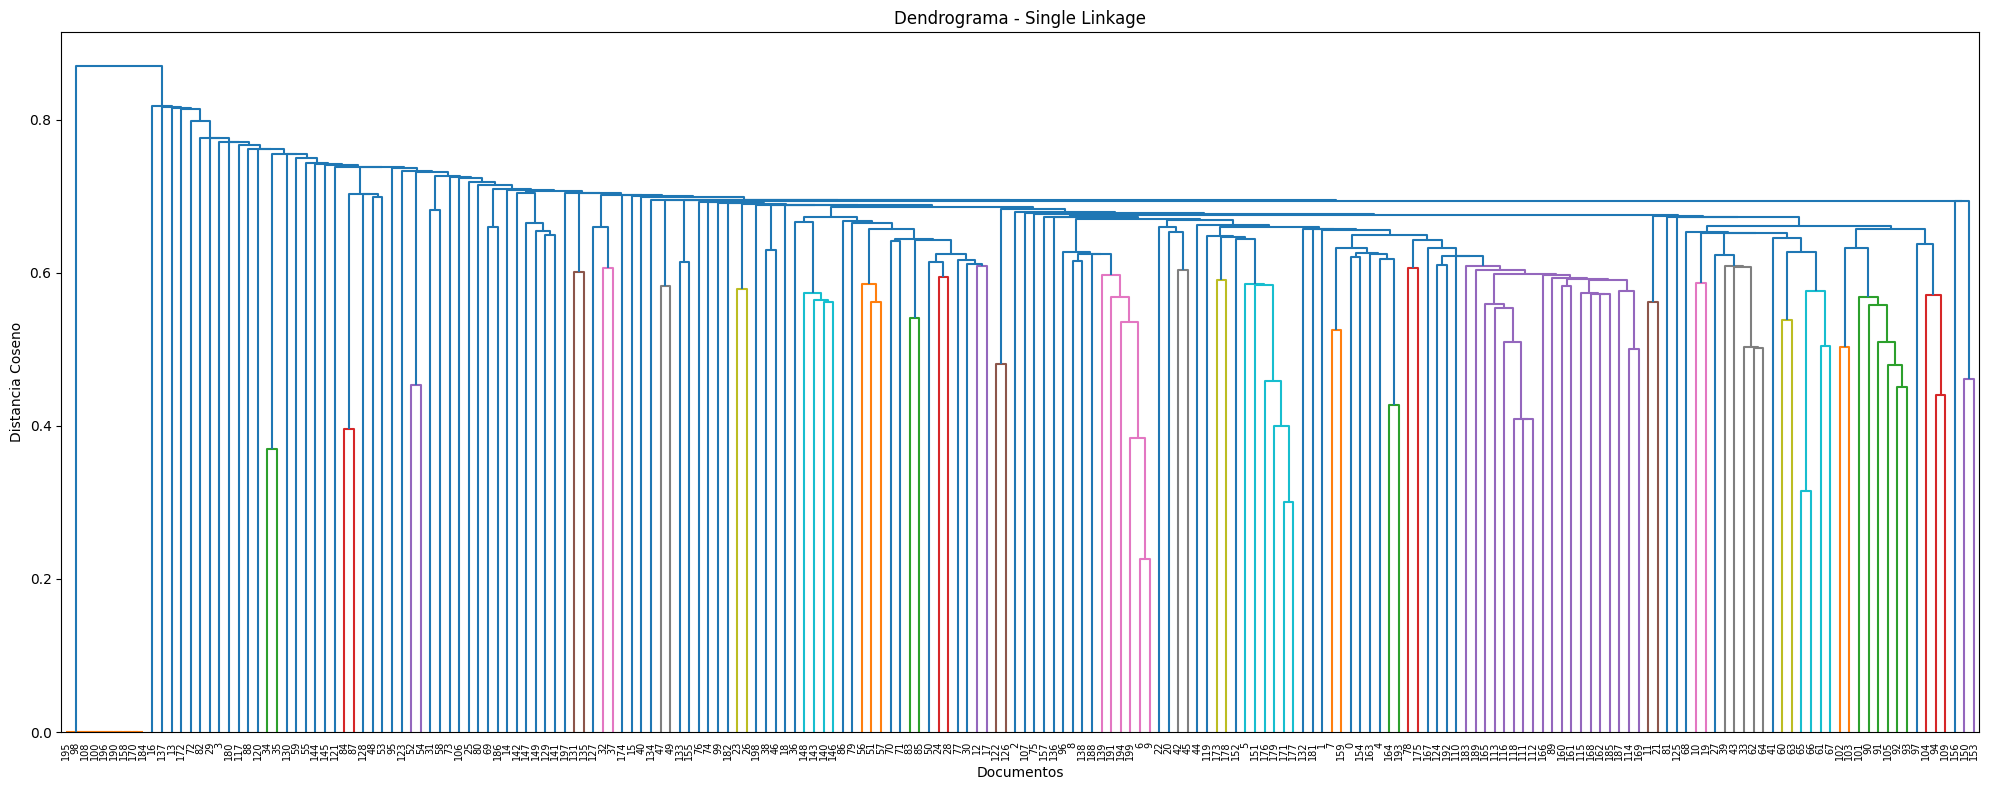

In [23]:
#Gráfico del dendrograma usando el linkage "single"
plt.figure(figsize=(20, 8))

dendrogram(
    Z_single,
    leaf_rotation=90,
    leaf_font_size=7
)

plt.title("Dendrograma - Single Linkage")
plt.xlabel("Documentos")
plt.ylabel("Distancia Coseno")

plt.tight_layout()
plt.show()

In [24]:
#Aplicar el agrupamiento jerárquico mediante el linkage complete
Z_complete = linkage(
    distancias,
    method='complete'
)

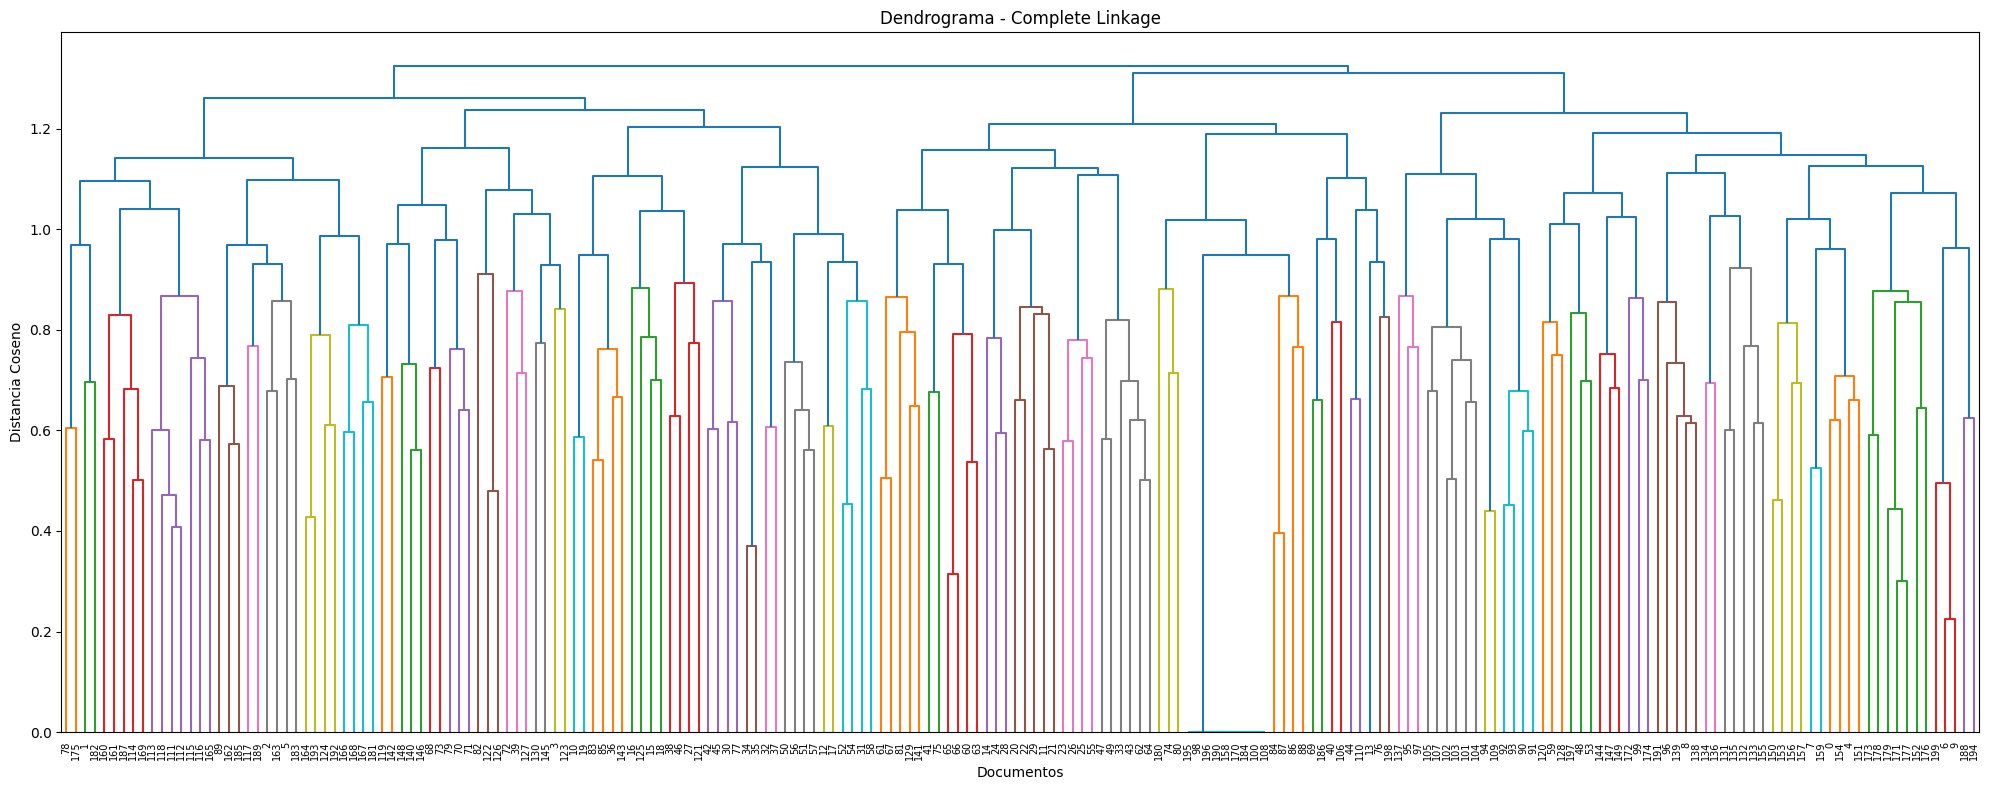

In [25]:
#Gráfico del dendrograma usando como linkage complete
plt.figure(figsize=(20, 8))

dendrogram(
    Z_complete,
    leaf_rotation=90,
    leaf_font_size=7
)

plt.title("Dendrograma - Complete Linkage")
plt.xlabel("Documentos")
plt.ylabel("Distancia Coseno")

plt.tight_layout()
plt.show()

In [26]:
#Obtener los clusters de Single, Complete y Average

from scipy.cluster.hierarchy import fcluster

clusters_single = fcluster(
    Z_single,
    t=20,
    criterion='maxclust'
)

clusters_complete = fcluster(
    Z_complete,
    t=20,
    criterion='maxclust'
)

clusters_average = fcluster(
    Z_average,
    t=20,
    criterion='maxclust'
)

###Métricas de validacion externa

In [27]:
#Importar las métricas necesarias
from sklearn.metrics import adjusted_rand_score, v_measure_score

In [28]:
#Calcular ARI para el Single Linkage, Complete Linkage y Average Linkage

ari_single = adjusted_rand_score(
    categorias_muestra,
    clusters_single
)

ari_complete = adjusted_rand_score(
    categorias_muestra,
    clusters_complete
)

ari_average = adjusted_rand_score(
    categorias_muestra,
    clusters_average
)

In [30]:
#Calcular V-measure para cada uno
v_single = v_measure_score(
    categorias_muestra,
    clusters_single
)

v_complete = v_measure_score(
    categorias_muestra,
    clusters_complete
)

v_average = v_measure_score(
    categorias_muestra,
    clusters_average
)

In [31]:
print("VALIDACIÓN EXTERNA")

print(f"Single   → ARI: {ari_single:.4f} | V-Measure: {v_single:.4f}")
print(f"Complete → ARI: {ari_complete:.4f} | V-Measure: {v_complete:.4f}")
print(f"Average  → ARI: {ari_average:.4f} | V-Measure: {v_average:.4f}")

VALIDACIÓN EXTERNA
Single   → ARI: -0.0002 | V-Measure: 0.1848
Complete → ARI: 0.2339 | V-Measure: 0.5672
Average  → ARI: 0.2957 | V-Measure: 0.6179


###Métricas de validación interna


In [32]:
#Importar la librería de la métrica
from sklearn.metrics import silhouette_score

In [33]:
silhouette_single = silhouette_score(
    embeddings_reducidos,
    clusters_single,
    metric='cosine'
)

silhouette_complete = silhouette_score(
    embeddings_reducidos,
    clusters_complete,
    metric='cosine'
)

silhouette_average = silhouette_score(
    embeddings_reducidos,
    clusters_average,
    metric='cosine'
)

In [34]:
print("VALIDACIÓN INTERNA")

print(f"Single   → Silhouette: {silhouette_single:.4f}")
print(f"Complete → Silhouette: {silhouette_complete:.4f}")
print(f"Average  → Silhouette: {silhouette_average:.4f}")

VALIDACIÓN INTERNA
Single   → Silhouette: -0.0831
Complete → Silhouette: 0.0840
Average  → Silhouette: 0.1204


#PARTE II:
Ejemplificar la segmentación de clientes usando clustering jerárquico. Use diferentes Linkages y explique sus hallazgos. [Hint: Podría usar el dataset: Mall Customer Dataset de Kaggle, uno sintético como make_blobs de scikit learn, u otro]

In [36]:
#Cargar el dataset

import pandas as pd

df_mall_customers = pd.read_csv("Mall_Customers.csv")

In [37]:
#Explorar el dataset

df_mall_customers.shape

(200, 5)

In [38]:
df_mall_customers.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [39]:
df_mall_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [40]:
df_mall_customers.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [41]:
#Verificar si existen valores nulos

df_mall_customers.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [42]:
#Seleccionar las variables para realizar el clustering
X = df_mall_customers[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].copy()

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [43]:
#Escalar las variables

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_escalado = scaler.fit_transform(X)

In [44]:
X_escalado

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

In [45]:
#Entrenamos los modelos de clustering jerárquicos
from scipy.cluster.hierarchy import linkage

Z_single_customers = linkage(
    distancias,
    method='single'
)

Z_complete_customers = linkage(
    distancias,
    method='complete'
)

Z_average_customers = linkage(
    distancias,
    method='average'
)

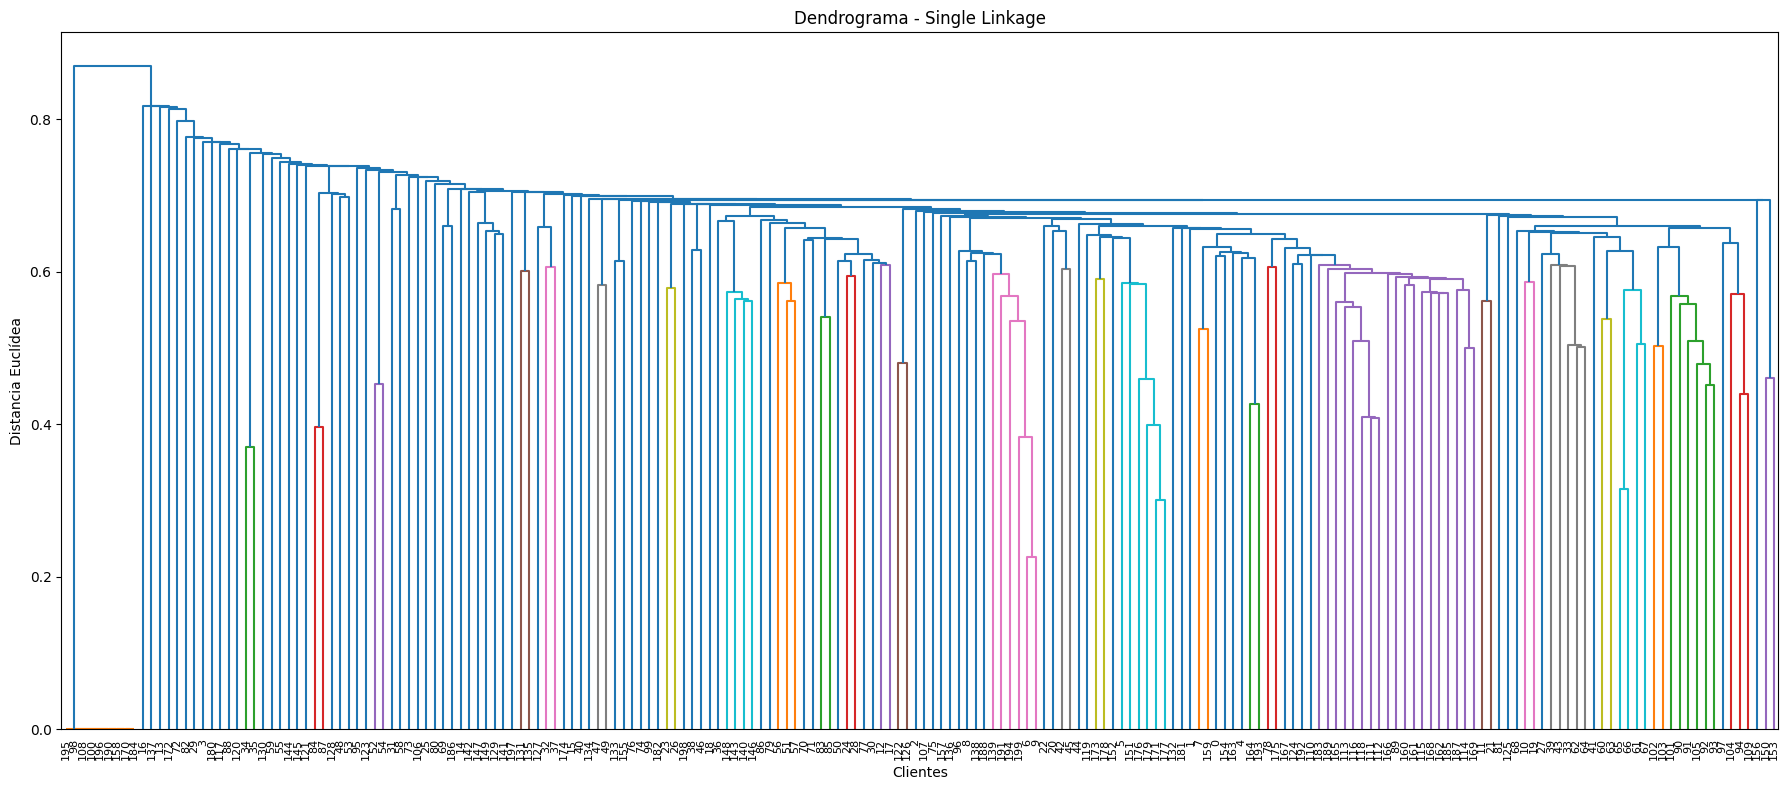

In [47]:
#Gráfico del dendrograma usando como linkage single
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 8))

dendrogram(
    Z_single_customers,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Dendrograma - Single Linkage")
plt.xlabel("Clientes")
plt.ylabel("Distancia Euclídea")
plt.tight_layout()
plt.show()

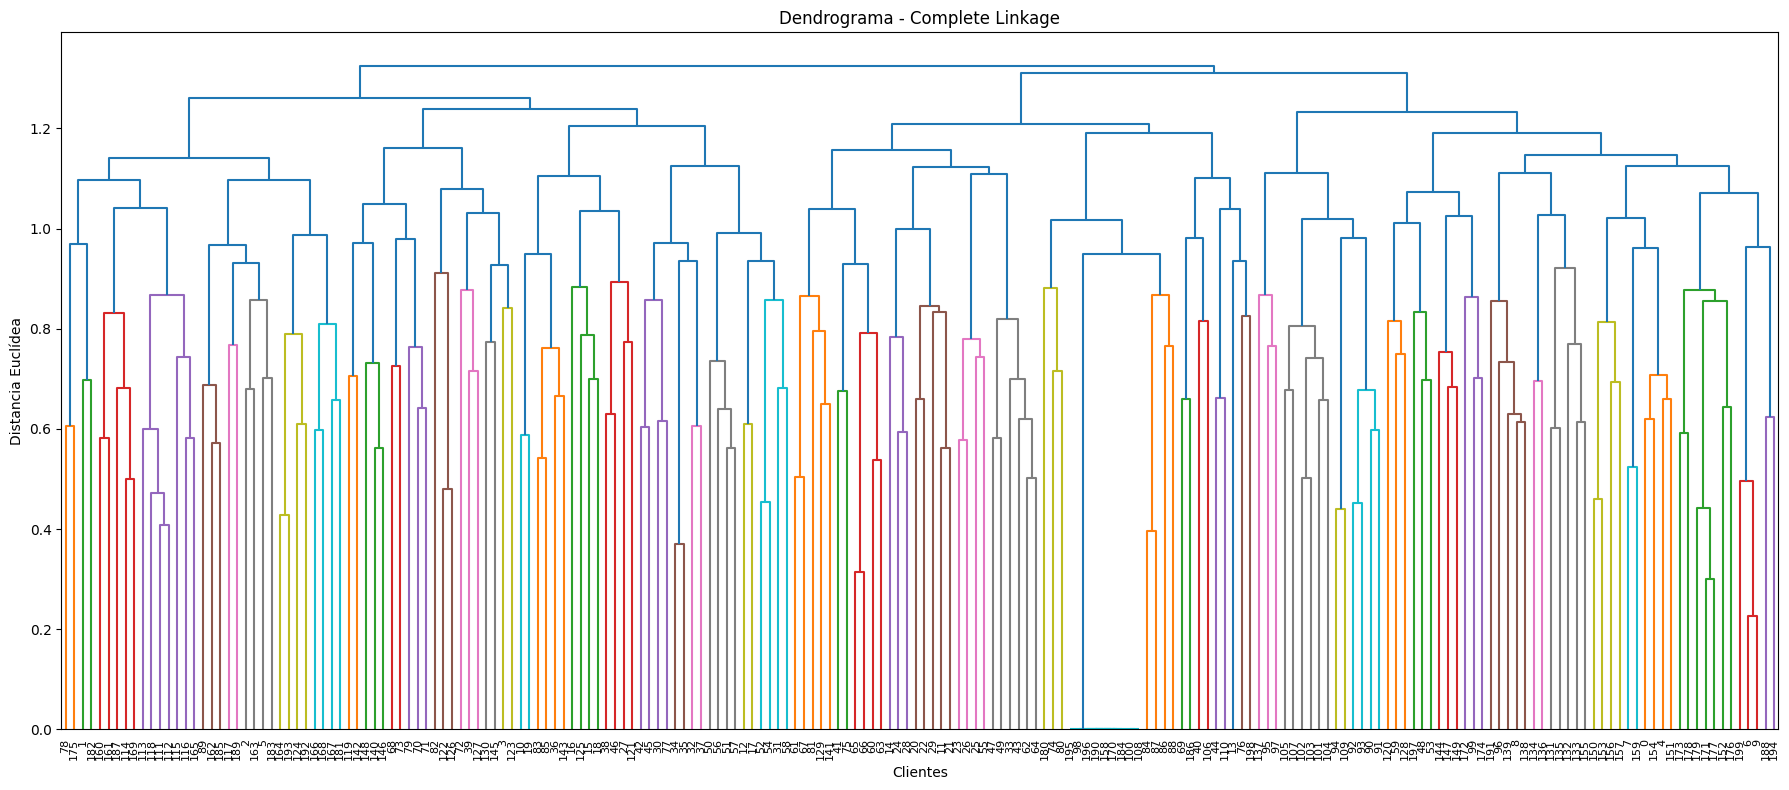

In [48]:
#Gráfico del dendrograma aplicando linkage complete
plt.figure(figsize=(18, 8))

dendrogram(
    Z_complete_customers,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Dendrograma - Complete Linkage")
plt.xlabel("Clientes")
plt.ylabel("Distancia Euclídea")
plt.tight_layout()
plt.show()

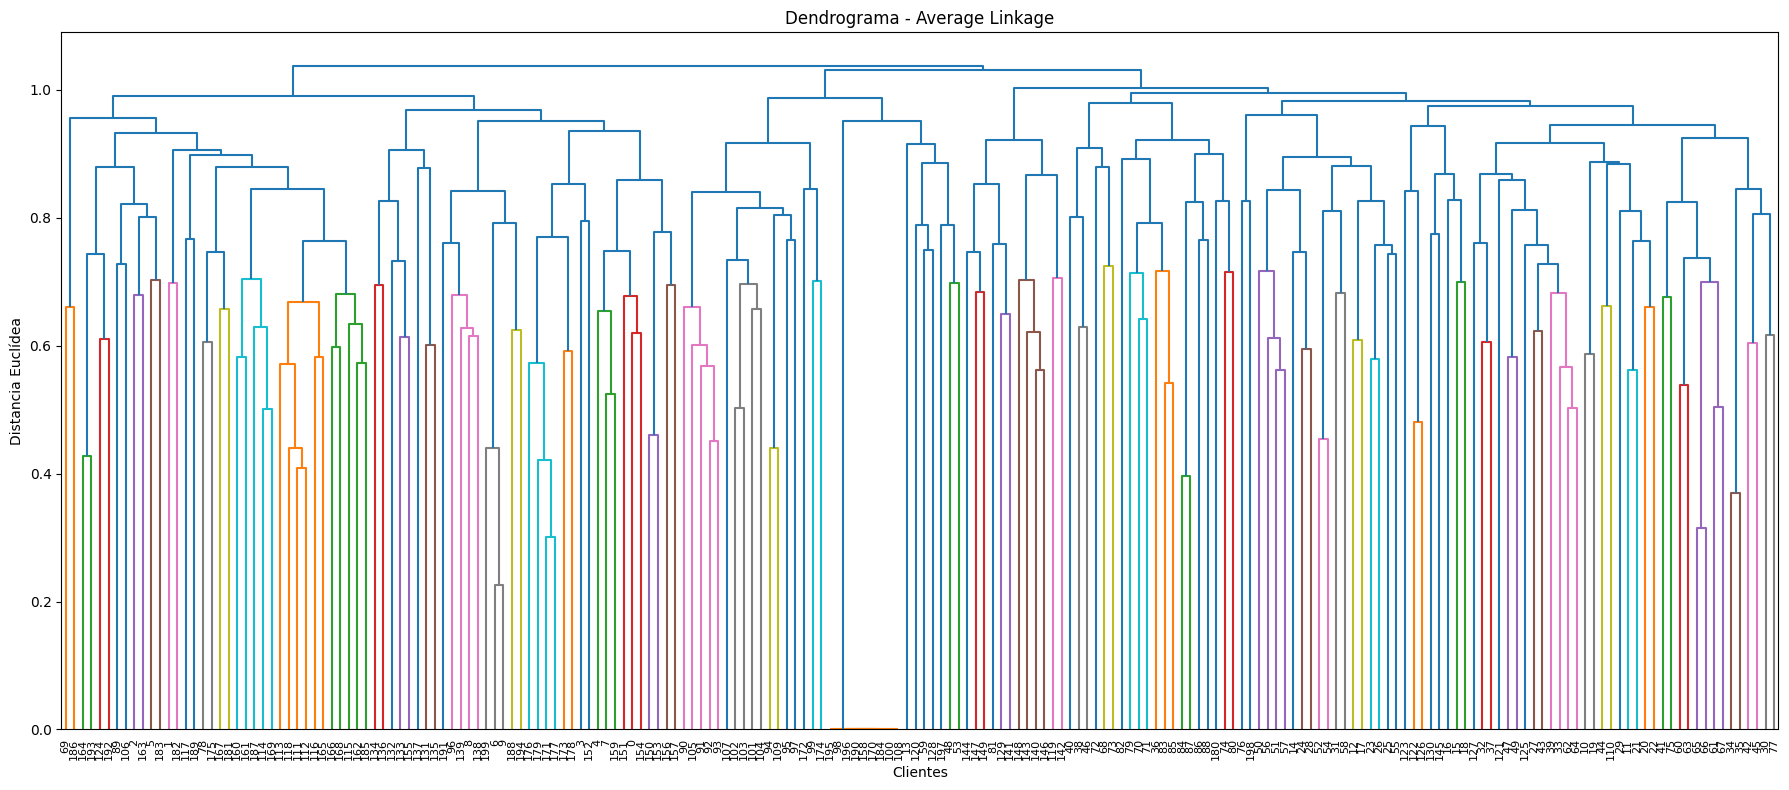

In [49]:
#Gráfico del dendrograma usando linkage average
plt.figure(figsize=(18, 8))

dendrogram(
    Z_average_customers,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Dendrograma - Average Linkage")
plt.xlabel("Clientes")
plt.ylabel("Distancia Euclídea")
plt.tight_layout()
plt.show()

In [52]:
#Cortar dendrograma en 5 clusters

from scipy.cluster.hierarchy import fcluster

clusters_single = fcluster(
    Z_single,
    t=5,
    criterion='maxclust'
)

clusters_complete = fcluster(
    Z_complete,
    t=5,
    criterion='maxclust'
)

clusters_average = fcluster(
    Z_average,
    t=5,
    criterion='maxclust'
)

In [54]:
#Verificar que etiquetas de cluster se generaron
import numpy as np

print("Single:", np.unique(clusters_single))
print("Complete:", np.unique(clusters_complete))
print("Average:", np.unique(clusters_average))

Single: [1 2 3 4 5]
Complete: [1 2 3 4 5]
Average: [1 2 3 4 5]


In [56]:
#Observación de los clientes distribuidos en cada clúster
print("Cantidad de clientes por cluster")

print("\nSingle:")
print(pd.Series(clusters_single).value_counts().sort_index())

print("\nComplete:")
print(pd.Series(clusters_complete).value_counts().sort_index())

print("\nAverage:")
print(pd.Series(clusters_average).value_counts().sort_index())

Cantidad de clientes por cluster

Single:
1      9
2    188
3      1
4      1
5      1
Name: count, dtype: int64

Complete:
1    33
2    20
3    32
4    54
5    61
Name: count, dtype: int64

Average:
1    72
2    33
3    12
4    20
5    63
Name: count, dtype: int64


#PARTE III:
Use clustering jerárquico para segmentar imágenes. Explique sus hallazgos [Hint: Podría usar el dataset BSDS500 u otro].

In [57]:
from google.colab import drive

In [58]:
drive.mount('/content/drive')

Mounted at /content/drive


In [63]:
import os  #Librería para trabajar con el sistema de archivos

ruta_train = "/content/drive/MyDrive/train" #Indicar la ruta en la que se encuentran las imágenes

#Almacenar las rutas de las imágenes qu encontremos
imagenes_train = [
    os.path.join(ruta_train, archivo)
    for archivo in os.listdir(ruta_train)
    if archivo.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Cantidad de imágenes:", len(imagenes_train))

Cantidad de imágenes: 200


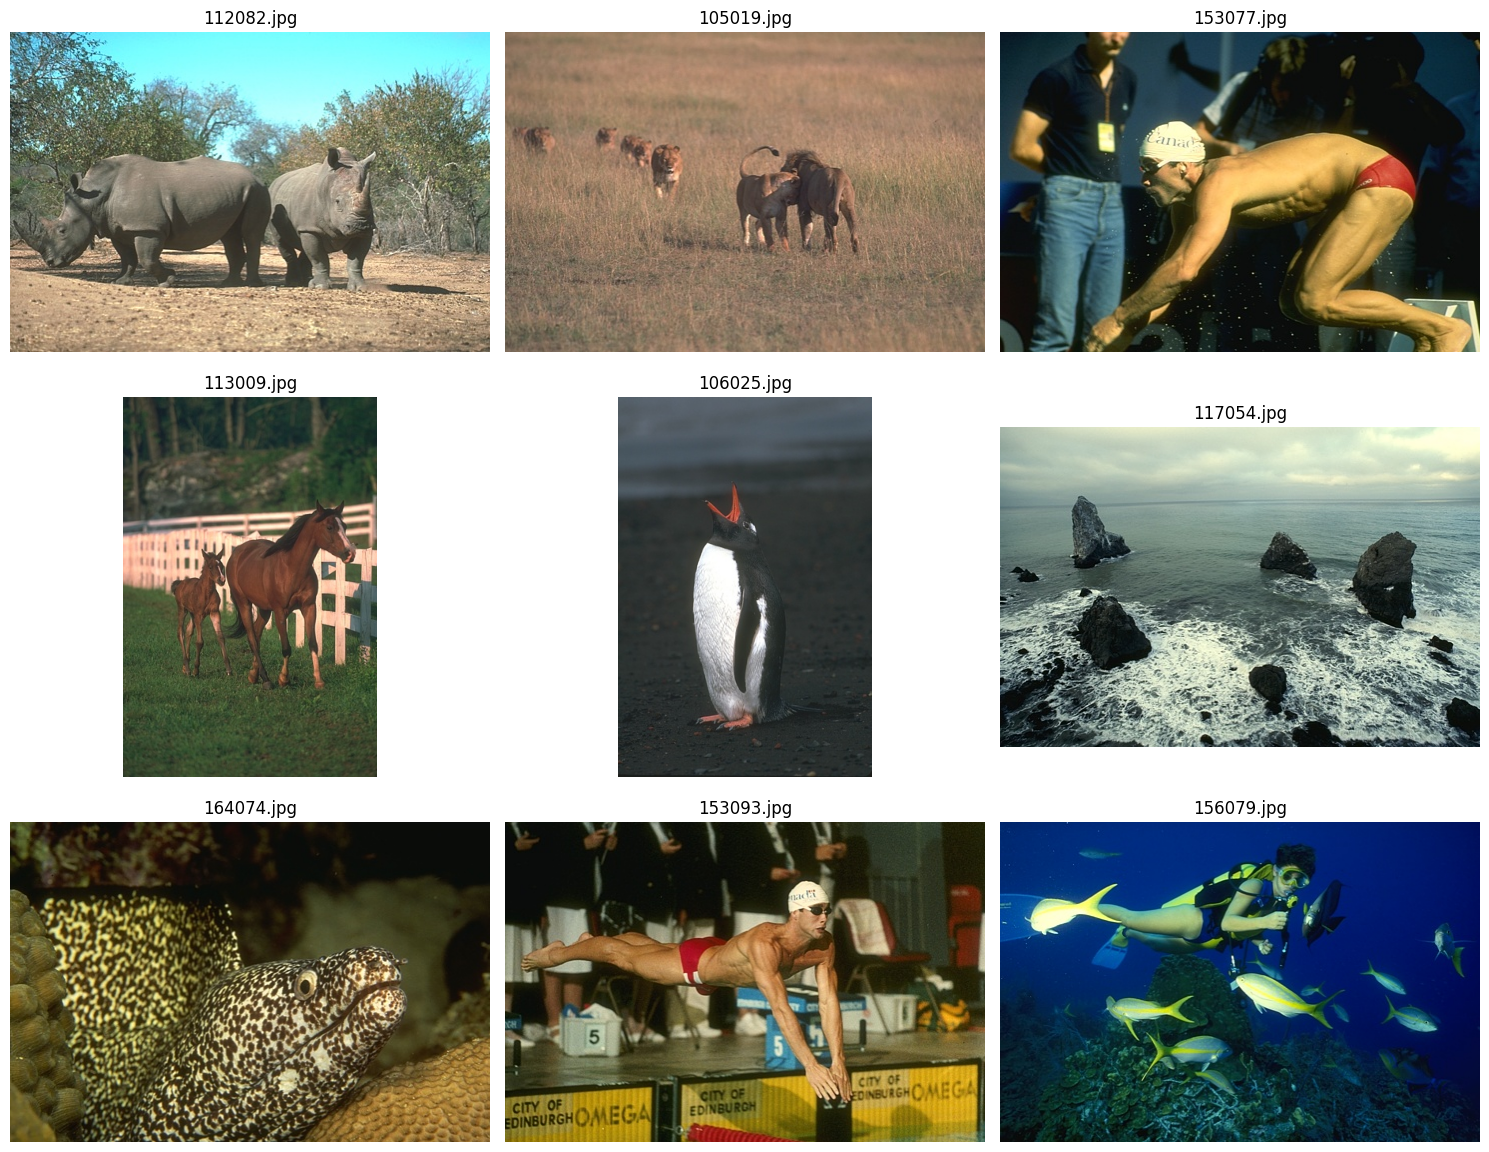

In [64]:
#Visualizar 9 imágenes y elegir una para hacer segmentación
from PIL import Image  #Importamos image para abrir y manipular imágenes
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(3, 3, figsize=(15, 12)) #Crear una cuadrícula de gráficos de 9 espacios (3 filas y 3 columnas)

#Recorremos los espacios de cuadrícula
for i, ax in enumerate(axes.flat):
    imagen = Image.open(imagenes_train[i]).convert("RGB") #Abrir imagen

    ax.imshow(imagen) #Mostrar la imagen
    ax.set_title(os.path.basename(imagenes_train[i])) #Añadir el nombre de la imagen
    ax.axis("off") #Quitar los ejes

plt.tight_layout()
plt.show()

113009.jpg
(321, 481)


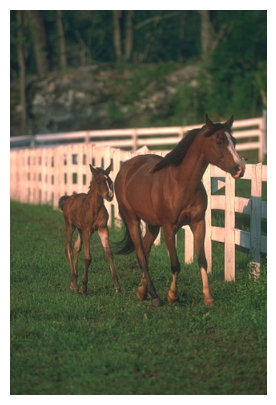

In [67]:

ruta_imagen = imagenes_train[3] #Seleccionar una imagen en este caso el 4 valores
imagen = Image.open(ruta_imagen).convert("RGB")  #Abrimos la imagen

print(os.path.basename(ruta_imagen)) #Mostramos el nombre del archivo
print(imagen.size) #Mostramos el tamaño de la imagen

plt.figure(figsize=(8, 5)) #Creamos una figura
plt.imshow(imagen) #Mostramos la imagen
plt.axis("off") #Quitamos los ejes
plt.show()

Tamaño original: (321, 481)
Tamaño reducido: (150, 150)


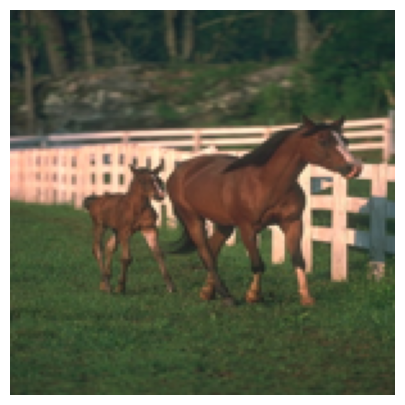

In [70]:
#Reducir el tamaño de la imagen
tamanio = (150, 150)

imagen_reducida = imagen.resize(tamanio)

print("Tamaño original:", imagen.size)
print("Tamaño reducido:", imagen_reducida.size)

plt.figure(figsize=(8, 5))
plt.imshow(imagen_reducida)
plt.axis("off")
plt.show()

In [71]:
#Convertir la imagen a una matriz Numpy

import numpy as np

pixeles = np.array(imagen_reducida)

print("Dimensiones:", pixeles.shape)
print("Primer píxel:", pixeles[0, 0])

Dimensiones: (150, 150, 3)
Primer píxel: [31 46 44]


In [72]:
#Convertir cada píxel en una observación
rgb = pixeles.reshape(-1, 3)

print("Matriz RGB:", rgb.shape)

Matriz RGB: (22500, 3)


In [73]:
#Normalizar los valores de RGB

rgb = rgb / 255.0

print(rgb[:5])

[[0.12156863 0.18039216 0.17254902]
 [0.11372549 0.16078431 0.15294118]
 [0.09019608 0.14509804 0.14509804]
 [0.11764706 0.17254902 0.16078431]
 [0.2        0.21960784 0.18431373]]


In [74]:
#Escalar las características

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_pixeles = scaler.fit_transform(rgb)

print("Dimensiones:", X_pixeles.shape)

Dimensiones: (22500, 3)


In [75]:
#Calculas las distancias

from scipy.spatial.distance import pdist

distancias = pdist(
    X_pixeles,
    metric="euclidean"
)

print("Cantidad de distancias:", len(distancias))

Cantidad de distancias: 253113750


In [76]:
from scipy.cluster.hierarchy import linkage

Z_single = linkage(
    distancias,
    method="single"
)

Z_complete = linkage(
    distancias,
    method="complete"
)

Z_average = linkage(
    distancias,
    method="average"
)

In [77]:
#Obtenemos los clusters
from scipy.cluster.hierarchy import fcluster

clusters_single = fcluster(
    Z_single,
    t=4,
    criterion="maxclust"
)

clusters_complete = fcluster(
    Z_complete,
    t=4,
    criterion="maxclust"
)

clusters_average = fcluster(
    Z_average,
    t=4,
    criterion="maxclust"
)

In [79]:
#Reconstruir los clusters en una imagen
segmentacion_single = clusters_single.reshape(150, 150)
segmentacion_complete = clusters_complete.reshape(150, 150)
segmentacion_average = clusters_average.reshape(150, 150)

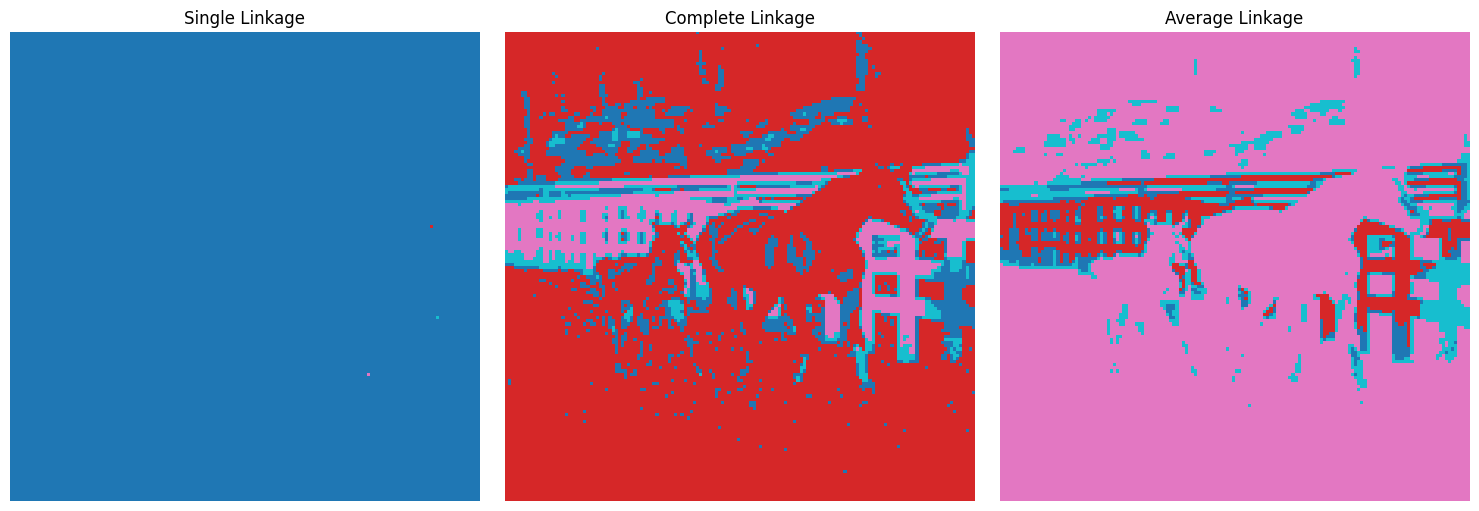

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(segmentacion_single, cmap="tab10")
axes[0].set_title("Single Linkage")
axes[0].axis("off")

axes[1].imshow(segmentacion_complete, cmap="tab10")
axes[1].set_title("Complete Linkage")
axes[1].axis("off")

axes[2].imshow(segmentacion_average, cmap="tab10")
axes[2].set_title("Average Linkage")
axes[2].axis("off")

plt.tight_layout()
plt.show()